# table of content

[1.curve text](#curve-text)

[2.align crop text](#align-crop-text)

[3.vertical dilate text](#vertical-dilate-text)

[4.check accuracy](#check-accuracy)

[5.check roi](#check-roi)

[6.v cut](#v-cut)

[7.histogram](#histogram)

[8.text discriminator](#text-discriminator)

[9.add image](#add-image)

# curve text

https://stackoverflow.com/questions/61725926/how-to-convert-curves-in-images-to-lines-in-python

# align crop text

https://stackoverflow.com/questions/42879716/straightening-contoured-rectangles-in-opencv-python

# vertical dilate text

https://stackoverflow.com/questions/59050090/using-dilation-in-only-one-direction

# check accuracy

# check roi

# add image

In [1]:
import cv2
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR

In [2]:
ocr = PaddleOCR(det_model_dir='models/ch_PP-OCRv3_det_infer',
                rec_model_dir='models/ch_PP-OCRv3_rec_infer',
                cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', 
                use_angle_cls=True)

[2023/01/18 12:54:11] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='models/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='totaltext', enable_mkldnn=False, four

img:  crop_120.jpg
mean:  219
Text:  Model: GXCA6 Coef:  0.766964852809906


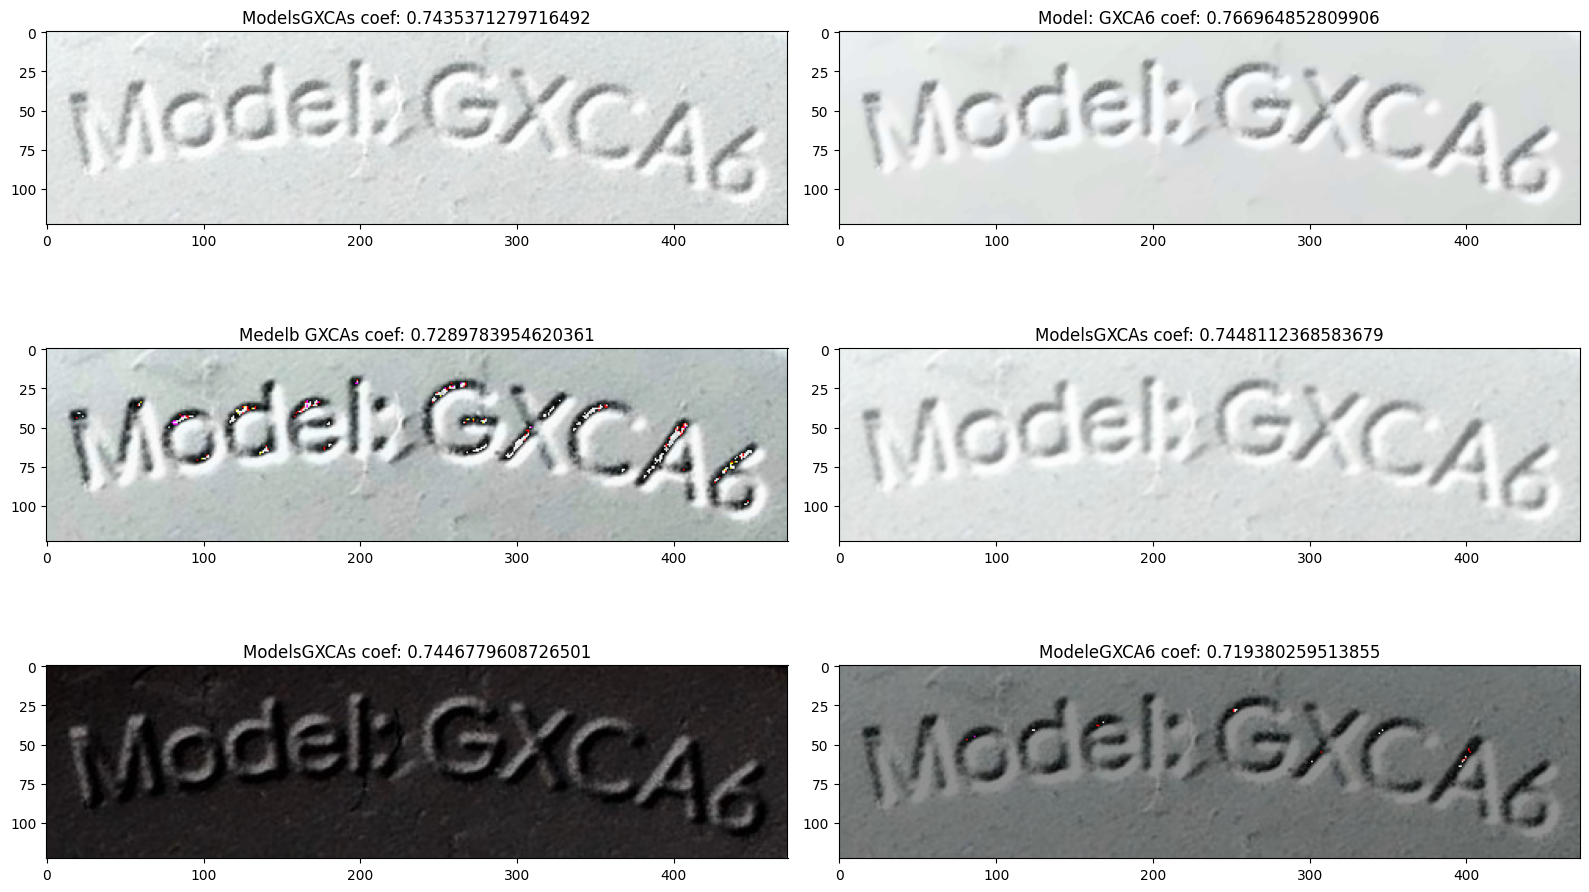

In [56]:
path = 'crops'

imgs = os.listdir(path)
img = random.choice(imgs)
print('img: ',img)

# original
img = cv2.imread(os.path.join(path,img))

# denoise
img2 = cv2.fastNlMeansDenoisingColored(img,None,3,3,7,21)

# denoise + orignal
img3 = img + img2

# blur
img4 = cv2.GaussianBlur(img,(3,3),0)

# reverse
img5 = 255 - img

# normalize
img6 = img - int(0.5*np.mean(img))

mean = np.mean(img).astype(np.uint8)
print('mean: ',mean)

imgs =[img,img2,img3,img4,img5,img6]
coef = []
text = []

for i in range(len(imgs)):
    im = imgs[i]
    t,c = ocr.ocr(im,det=False,rec=True,cls=True)[0][0]
    text.append(t)
    coef.append(c)

i = np.argmax(coef)
t = text[i]
c = coef[i]

print("Text: ",t,"Coef: ",c)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16,10))

axes[0][0].imshow(img)
axes[0][0].set_title(f"{text[0]} coef: {coef[0]}")

axes[0][1].imshow(img2)
axes[0][1].set_title(f"{text[1]} coef: {coef[1]}")

axes[1][0].imshow(img3)
axes[1][0].set_title(f"{text[2]} coef: {coef[2]}")

axes[1][1].imshow(img4)
axes[1][1].set_title(f"{text[3]} coef: {coef[3]}")

axes[2][0].imshow(img5)
axes[2][0].set_title(f"{text[4]} coef: {coef[4]}")

axes[2][1].imshow(img6)
axes[2][1].set_title(f"{text[5]} coef: {coef[5]}")

plt.tight_layout()

# references

[using-dilation-in-only-one-direction](https://stackoverflow.com/questions/59050090/using-dilation-in-only-one-direction)

[straightening-contoured-rectangles](https://stackoverflow.com/questions/42879716/straightening-contoured-rectangles-in-opencv-python)

[How to convert curves in images to lines in Python?](https://stackoverflow.com/questions/61725926/how-to-convert-curves-in-images-to-lines-in-python)

[paddleocr](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/paddleocr.py)

[OPENCV: 'FAST' LIKE CORNER DETECTION WITH SCANNING WINDOW](http://dsynflo.blogspot.com/2014/07/opencv-fast-like-corner-detection-with.html)

[006 Morphological transformations with OpenCV in Python](https://datahacker.rs/006-morphological-transformations-with-opencv-in-python/)

[Morphological Transformations](https://docs.opencv.org/3.4/d4/d76/tutorial_js_morphological_ops.html)

[Image Denoising](https://docs.opencv.org/3.4/d5/d69/tutorial_py_non_local_means.html)

[Basics of Brute-Force Matcher](https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html)